In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import warnings
warnings.filterwarnings("ignore")

In [3]:
from datasets import load_dataset

dataset = load_dataset("legacy-datasets/banking77")
dataset

README.md:   0%|          | 0.00/14.4k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  298kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 93.9kB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/10003 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3080 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 10003
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 3080
    })
})

In [4]:
train_text = dataset['train']['text']
train_text

Column(['I am still waiting on my card?', "What can I do if my card still hasn't arrived after 2 weeks?", 'I have been waiting over a week. Is the card still coming?', 'Can I track my card while it is in the process of delivery?', 'How do I know if I will get my card, or if it is lost?'])

In [5]:
train_label = dataset['train']['label']
train_label

Column([11, 11, 11, 11, 11])

In [6]:
test_text = dataset['test']['text']
test_text

Column(['How do I locate my card?', 'I still have not received my new card, I ordered over a week ago.', 'I ordered a card but it has not arrived. Help please!', 'Is there a way to know when my card will arrive?', 'My card has not arrived yet.'])

In [7]:
test_label = dataset['test']['label']
test_label

Column([11, 11, 11, 11, 11])

In [8]:
label_names = dataset['train'].features['label'].names
label_names

['activate_my_card',
 'age_limit',
 'apple_pay_or_google_pay',
 'atm_support',
 'automatic_top_up',
 'balance_not_updated_after_bank_transfer',
 'balance_not_updated_after_cheque_or_cash_deposit',
 'beneficiary_not_allowed',
 'cancel_transfer',
 'card_about_to_expire',
 'card_acceptance',
 'card_arrival',
 'card_delivery_estimate',
 'card_linking',
 'card_not_working',
 'card_payment_fee_charged',
 'card_payment_not_recognised',
 'card_payment_wrong_exchange_rate',
 'card_swallowed',
 'cash_withdrawal_charge',
 'cash_withdrawal_not_recognised',
 'change_pin',
 'compromised_card',
 'contactless_not_working',
 'country_support',
 'declined_card_payment',
 'declined_cash_withdrawal',
 'declined_transfer',
 'direct_debit_payment_not_recognised',
 'disposable_card_limits',
 'edit_personal_details',
 'exchange_charge',
 'exchange_rate',
 'exchange_via_app',
 'extra_charge_on_statement',
 'failed_transfer',
 'fiat_currency_support',
 'get_disposable_virtual_card',
 'get_physical_card',
 'gett

In [9]:
df_train = pd.DataFrame({
    'text' : train_text,
    'label':[label_names[i] for i in train_label]
})



In [10]:
df_train.head(5)

,text,label
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [11]:
df_train.shape

(10003, 2)

In [12]:
df_train.tail(5)

,text,label
9998,You provide support in what countries?,country_support
9999,What countries are you supporting?,country_support
10000,What countries are getting support?,country_support
10001,Are cards available in the EU?,country_support
10002,Which countries are represented?,country_support


In [13]:
df_test = pd.DataFrame({
    'test'  :test_text,
    'label' :[label_names[i] for i in test_label]
})

df_test.head()

,test,label
0,How do I locate my card?,card_arrival
1,"I still have not received my new card, I order...",card_arrival
2,I ordered a card but it has not arrived. Help ...,card_arrival
3,Is there a way to know when my card will arrive?,card_arrival
4,My card has not arrived yet.,card_arrival


In [14]:
df_test.shape

(3080, 2)

In [15]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10003 entries, 0 to 10002
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10003 non-null  object
 1   label   10003 non-null  object
dtypes: object(2)
memory usage: 156.4+ KB


In [16]:
df_train.isnull().sum()

,0
text,0
label,0


In [17]:
df_train.duplicated().sum()

np.int64(0)

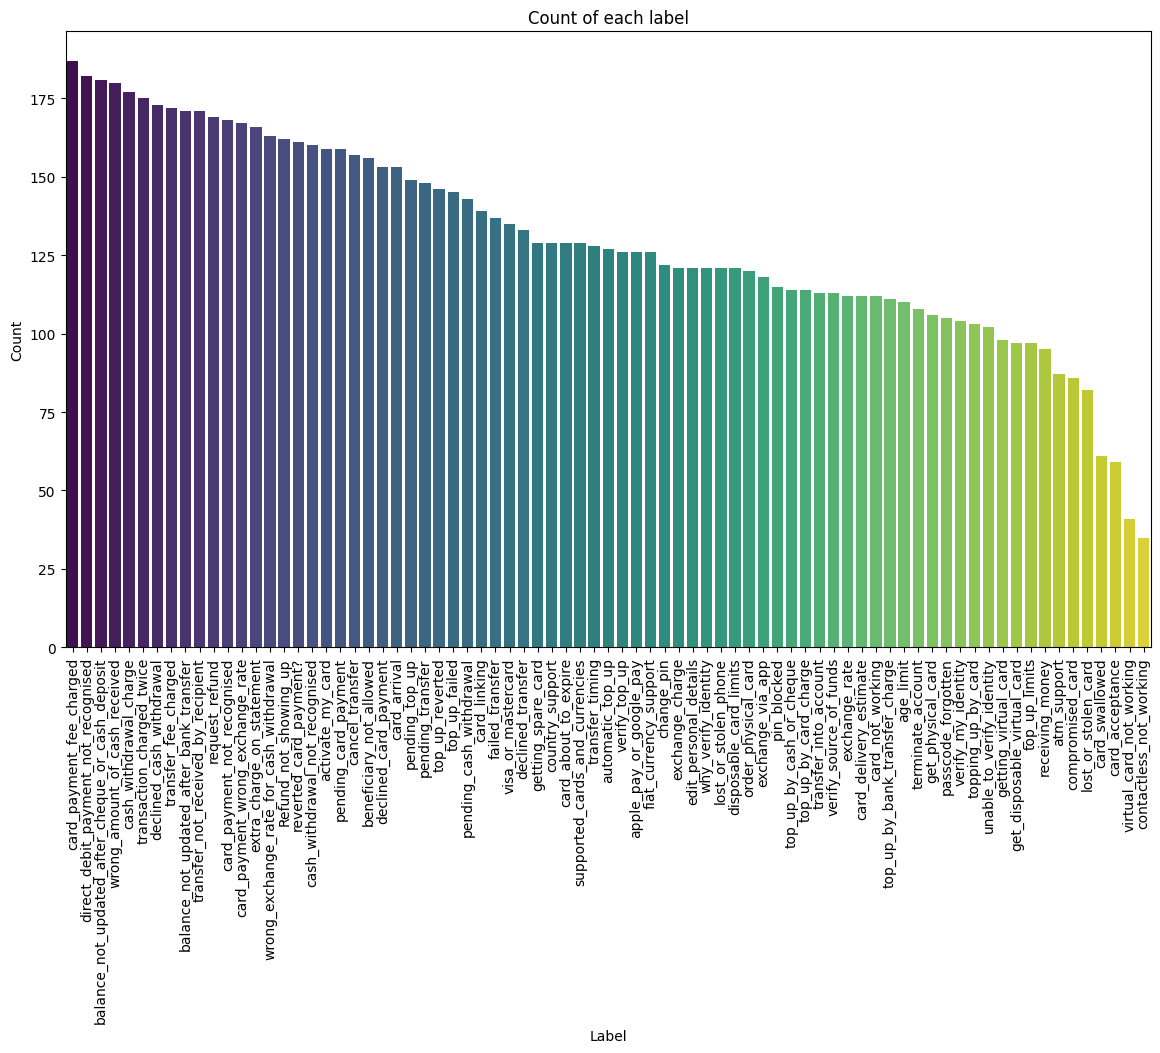

In [18]:
plt.figure(figsize=(14,8))
ex = sns.countplot(x = 'label',data = df_train,palette='viridis',order = df_train['label'].value_counts().index)
plt.title('Count of each label')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

count    10003.000000
mean        11.949415
std          7.891577
min          2.000000
25%          7.000000
50%         10.000000
75%         13.000000
max         79.000000
Name: sentence_length, dtype: float64


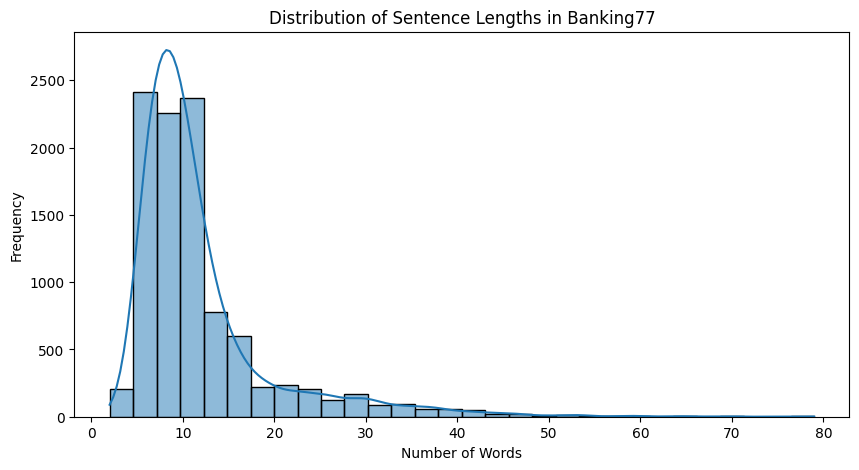

In [19]:
import matplotlib.pyplot as plt

# Number of words in each sentence
df_train['sentence_length'] = df_train['text'].apply(lambda x: len(x.split()))

# Basic statistics
print(df_train['sentence_length'].describe())

# Plot distribution
plt.figure(figsize=(10,5))
sns.histplot(x = 'sentence_length',data = df_train,bins=30,kde=True)
plt.title('Distribution of Sentence Lengths in Banking77')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

In [20]:
df_train = df_train.drop(columns=['sentence_length'])
display(df_train.head())

,text,label
0,I am still waiting on my card?,card_arrival
1,What can I do if my card still hasn't arrived ...,card_arrival
2,I have been waiting over a week. Is the card s...,card_arrival
3,Can I track my card while it is in the process...,card_arrival
4,"How do I know if I will get my card, or if it ...",card_arrival


In [21]:
import re
import string

In [22]:
def preprocess_text(text):
  text = text.lower()
  text = text.translate(str.maketrans('','',string.punctuation))
  return text


train_text = df_train['text'].apply(preprocess_text)
train_text.head()

,text
0,i am still waiting on my card
1,what can i do if my card still hasnt arrived a...
2,i have been waiting over a week is the card st...
3,can i track my card while it is in the process...
4,how do i know if i will get my card or if it i...


In [23]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [24]:
vocab_size = 2396
max_len = 30

tokenizer = Tokenizer(num_words = vocab_size,oov_token='<oov>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequence = tokenizer.texts_to_sequences(df_test['test'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=max_len,padding='post',truncating='post')
padded_test_sequence = pad_sequences(test_sequence,maxlen=max_len,padding='post',truncating='post')

In [25]:
print(df_train.columns)
print(df_test.columns)

Index(['text', 'label'], dtype='object')
Index(['test', 'label'], dtype='object')


In [26]:
print(padded_train_sequence.shape)
print(padded_test_sequence.shape)

(10003, 30)
(3080, 30)


In [27]:
print(f"vocabulary size : {len(tokenizer.word_index)}")

vocabulary size : 2396


In [28]:
train_labels = np.array([label_names.index(label) for label in df_train['label']])

from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_labels),
    y  = train_labels
)

class_weight_dict = dict(enumerate(class_weights))
class_weight_dict


{0: np.float64(0.8170383076043454),
 1: np.float64(1.1809917355371902),
 2: np.float64(1.031024531024531),
 3: np.float64(1.4932079414838035),
 4: np.float64(1.022906227630637),
 5: np.float64(0.7597022860180755),
 6: np.float64(0.7177297840281266),
 7: np.float64(0.8327505827505828),
 8: np.float64(0.827446438911407),
 9: np.float64(1.0070472163495419),
 10: np.float64(2.201848998459168),
 11: np.float64(0.8490790255496138),
 12: np.float64(1.1599025974025974),
 13: np.float64(0.934597776324395),
 14: np.float64(1.1599025974025974),
 15: np.float64(0.6947010209042295),
 16: np.float64(0.7732683982683982),
 17: np.float64(0.7778987479586282),
 18: np.float64(2.1296572280178836),
 19: np.float64(0.733949666153056),
 20: np.float64(0.8119318181818181),
 21: np.float64(1.0648286140089418),
 22: np.float64(1.5105708245243128),
 23: np.float64(3.7116883116883117),
 24: np.float64(1.0070472163495419),
 25: np.float64(0.8490790255496138),
 26: np.float64(0.7509196006305833),
 27: np.float64(0

In [29]:
test_labels = np.array(test_label)
test_labels

array([11, 11, 11, ..., 24, 24, 24])

In [30]:
num_classes = len(np.unique(train_labels))
num_classes

77

In [31]:


from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Early Stopping
early_stop = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True,verbose=1)

# Reduce Learning Rate
reduce_lr = ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=2,min_lr=1e-5,verbose=1)

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,Dense,Dropout,GRU

In [33]:
from tensorflow.keras.layers import Bidirectional

In [34]:
BiGRU = Sequential([
    Embedding(input_dim = vocab_size,output_dim = 300, input_length = max_len),
    Bidirectional(GRU(units = 128,return_sequences=True)),
    Dropout(0.2),
    Bidirectional(GRU(units = 64)),
    Dropout(0.2),
    Dense(units=num_classes,activation='softmax'),
])


BiGRU.compile(optimizer = 'adam',loss = 'sparse_categorical_crossentropy',metrics=['accuracy'])

In [36]:
history = BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs=25,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 257ms/step - accuracy: 0.5413 - loss: 1.7356 - val_accuracy: 0.7120 - val_loss: 1.1806 - learning_rate: 0.0010
Epoch 2/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 220ms/step - accuracy: 0.7665 - loss: 0.8994 - val_accuracy: 0.8010 - val_loss: 0.7849 - learning_rate: 0.0010
Epoch 3/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 222ms/step - accuracy: 0.8528 - loss: 0.5613 - val_accuracy: 0.8367 - val_loss: 0.6374 - learning_rate: 0.0010
Epoch 4/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 70s 224ms/step - accuracy: 0.8993 - loss: 0.3797 - val_accuracy: 0.8503 - val_loss: 0.5760 - learning_rate: 0.0010
Epoch 5/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 69s 220ms/step - accuracy: 0.9247 - loss: 0.2748 - val_accuracy: 0.8445 - val_loss: 0.5809 - learning_rate: 0.0010
Epoch 6/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 81s 217ms/step - accuracy: 0.9421 - loss: 0.2130 - val_accuracy: 0.8591 - val_loss: 0.5498 - learning_rate: 0.0010
Epoch 7/25
313/313 ━━━━━━━━━━━━━━━━━━━━ 68s 216ms/step - accuracy: 0.9

In [37]:
test_loss, test_acc = BiGRU.evaluate(
    padded_test_sequence,
    test_labels,
    verbose=1
)

print("Final Test Loss:", test_loss)
print("Final Test Accuracy:", test_acc)

97/97 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.8685 - loss: 0.5464
Final Test Loss: 0.5463969707489014
Final Test Accuracy: 0.8685064911842346


In [38]:
sample_texts = [
    "I want to activate my new card before using it.",                  # activate_my_card
    "Why is my contactless payment not working at stores?",                  # contactless_not_working
    "I was charged an extra fee when exchanging currency abroad.",           # exchange_charge
    "My identity verification keeps getting rejected.",                     # verify_my_identity
    "The exchange rate used for my cash withdrawal is incorrect.",          # wrong_exchange_rate_for_cash_withdrawal
    "I cannot link my existing card to the app.",                           # card_linking
    "What is the maximum amount I can top up using my card?",               # top_up_limits
    "My transfer has not reached the recipient yet.",                      # transfer_not_received_by_recipient
    "I need a virtual card for online shopping.",                           # getting_virtual_card
    "Why do I need to verify my identity to use my account?"               # why_verify_identity
]

# Preprocess
sample_texts = [preprocess_text(text) for text in sample_texts]

# Convert text to sequences
sample_sequences = tokenizer.texts_to_sequences(sample_texts)

# Pad sequences
sample_padded_sequences = pad_sequences(
    sample_sequences,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

# Predict
sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

# Display results
for i in range(len(sample_texts)):
    print(f"Text: {sample_texts[i]}")
    print(f"Predicted Intent: {label_names[sample_predictions[i]]}")
    print("-" * 60)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 920ms/step
Text: i want to activate my new card before using it
Predicted Intent: activate_my_card
------------------------------------------------------------
Text: why is my contactless payment not working at stores
Predicted Intent: contactless_not_working
------------------------------------------------------------
Text: i was charged an extra fee when exchanging currency abroad
Predicted Intent: card_payment_wrong_exchange_rate
------------------------------------------------------------
Text: my identity verification keeps getting rejected
Predicted Intent: unable_to_verify_identity
------------------------------------------------------------
Text: the exchange rate used for my cash withdrawal is incorrect
Predicted Intent: wrong_exchange_rate_for_cash_withdrawal
------------------------------------------------------------
Text: i cannot link my existing card to the app
Predicted Intent: card_linking
----------------------------------------------------

In [39]:
import pickle

# Save model
BiGRU.save("BiGRU_model.keras")

# Save tokenizer
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save label names
with open("label_names.pkl", "wb") as f:
    pickle.dump(label_names, f)

print("Model, tokenizer and labels saved successfully!")

Model, tokenizer and labels saved successfully!
